In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import matplotlib.image as image

In [2]:
sys.path.insert(1, './utils/')

In [3]:
from load_data import *
from plot_functions import *
from utils_functions import *

# FIGURE 2 or 3
Change the figure parameter accordingly

In [23]:
figure = 's4' #3
network = 'plastic_bipolar'
save_name = f"../Figures/Figure_{figure}"
save = True
circuit_scheme = 'schemes/scheme_M2_plastic_bipolar.png'

## Load Simulation Results

In [24]:

fn = 12

       
#simulation_fixed = load_dict(f'data/simulation_osr_fixed_{fn}.pickle')
simulation_dynamic = load_dict(f'../output/params_final_ON_excitatory/simulation_osr_{fn}.pickle')


#simulation_dynamic = load_dict(f'data/simulation_osr_dynamic_{fn}.pickle')
simulation_fixed = load_dict(f'../output/params_final_ON_excitatory_fixed/simulation_osr_{fn}.pickle')



keys = ['6_Hz', '12_Hz', '16_Hz']

frequencies = simulation_dynamic['osrparams']['frequencies']
periods = np.round(1/frequencies,2)*1000

times = [simulation_dynamic['simulations'][key]['time']-simulation_dynamic['simulations'][key]['lastflash_tp']
         for key in keys]
#time2 = simulation2['simulations'][key]['time']

flashes =[np.where(np.diff(simulation_dynamic['simulations'][key]['stimulus']) != 0)[0].tolist() for key in keys]

lastflashends = [simulation_dynamic['simulations'][key]['lastflash_tp'] for key in keys]
#lastflashend2 = simulation2['simulations'][key]['lastflash_tp']


# simulation dynamic
responses_dynamic = [simulation_dynamic['simulations'][key]['RG'] for key in keys]
delays_dynamic = [simulation_dynamic['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic = [simulation_dynamic['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_dynamic = simulation_dynamic['delays']*1000
slope_dynamic = simulation_dynamic['slope']
offset_dynamic =  simulation_dynamic['offset']*1000 

delays_all_dynamic_relative = delays_all_dynamic - delays_all_dynamic[-1]
offset_dynamic_relative =  simulation_dynamic['offset']*1000 - delays_all_dynamic[-1]


# simulation fixed
responses_fixed = [simulation_fixed['simulations'][key]['RG'] for key in keys]
delays_fixed = [simulation_fixed['simulations'][key]['delay'] for key in keys]
peak_amps_fixed = [simulation_fixed['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_fixed = simulation_fixed['delays']*1000
slope_fixed = simulation_fixed['slope']
offset_fixed =  simulation_fixed['offset']*1000

delays_all_fixed_relative = delays_all_fixed - delays_all_dynamic[-1]
offset_fixed_relative =  simulation_fixed['offset']*1000 - delays_all_dynamic[-1]

# load circuit image
circuit_scheme = image.imread(circuit_scheme)


omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]

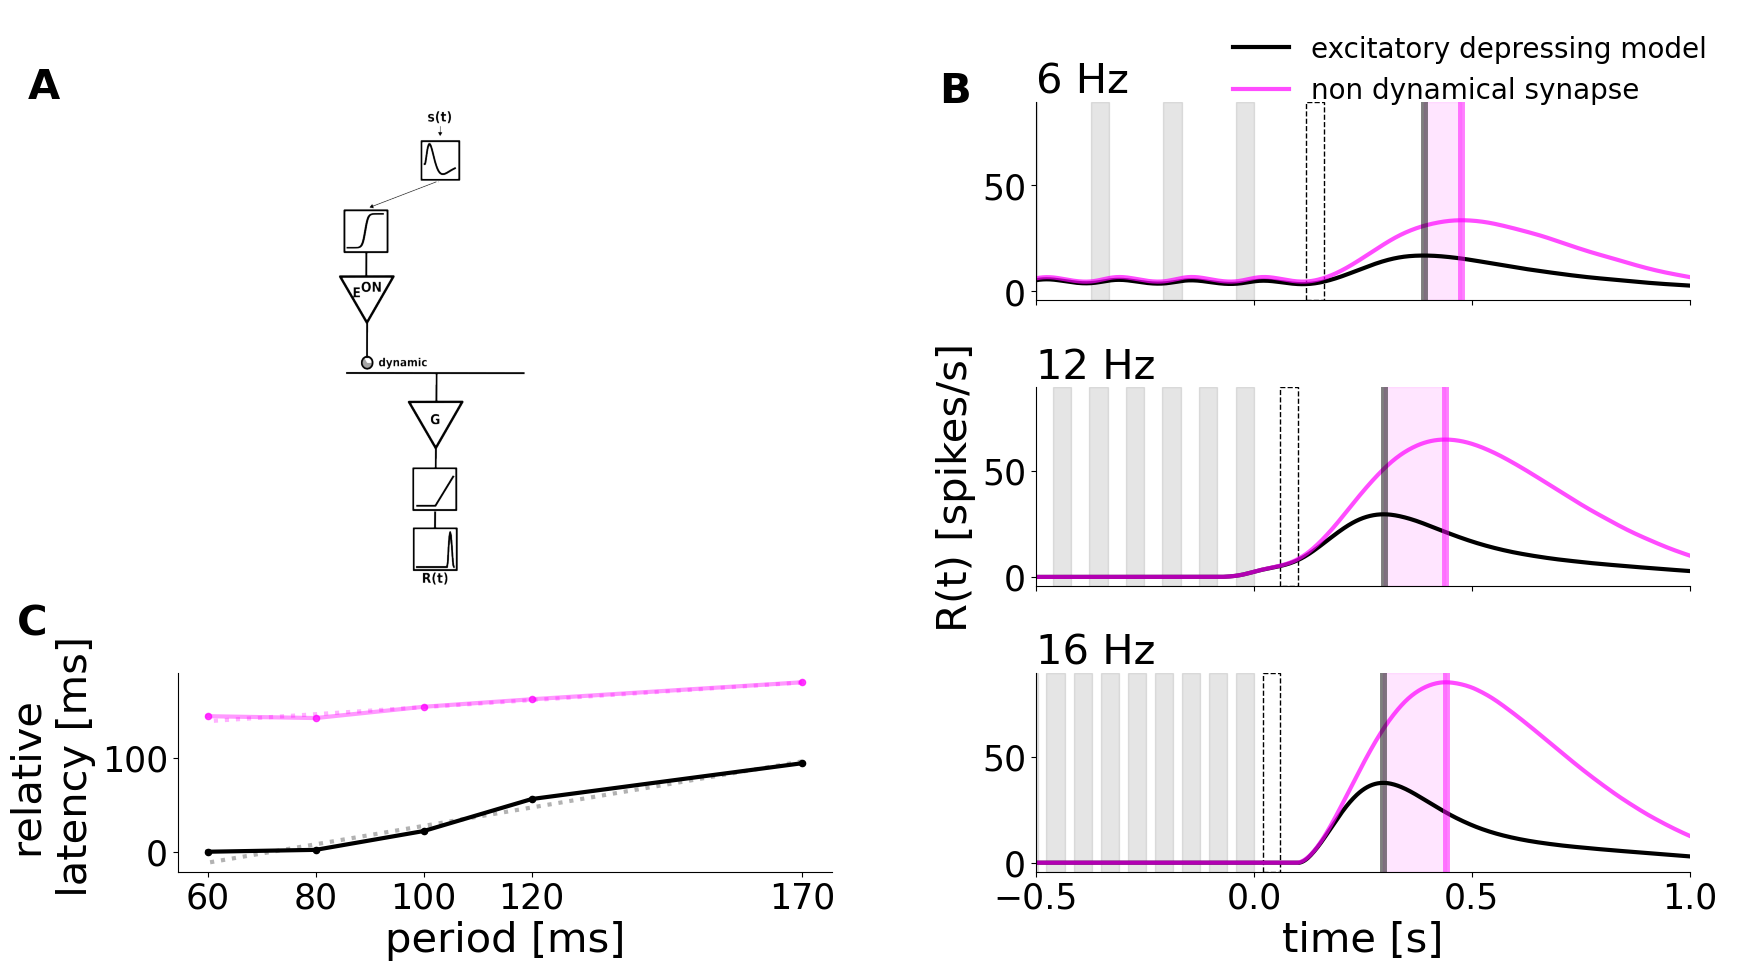

In [27]:


#figure parameter

fontsize_legend = 20
fontsize_labels = 30
fontsize_panellabel = 30
fontsize_ticks = 25
lw = 3
ms = 20
panellabel_position = [-0.2, 1.15]
frequencytext_position = [0.15,1.1]
figsize_ratio = 5
nrows = 3
ncols = 6

# figsize = (ncols*figsize_ratio, nrows*figsize_ratio)
figsize = (18,10)

save =True
show = True
image_format = "png"
dpi = 300

cond_labels = ["excitatory depressing model", "non dynamical synapse"]
    
frequencies_displayed = [6,12,16]
    
color_control = "k"
color_test = "magenta"
alpha_test = .7

#initialize figure
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(nrows,ncols)
fig.tight_layout()

fig.patch.set_facecolor('white')


fig.subplots_adjust(top=0.88,
bottom=0.11,
left=0.11,
right=0.95,
hspace=0.44,
wspace=2.5)


#####################################################################################################################
# create panels
#####################################################################################################################

A = fig.add_subplot(gs[:-1,:3], frameon = False)

B = fig.add_subplot(gs[0,3:], frameon = False)
B0 = fig.add_subplot(gs[0,3:])
B1 = fig.add_subplot(gs[1,3:], sharey = B0, sharex = B0)
B2 = fig.add_subplot(gs[2,3:], sharey = B0, sharex = B0)

C = fig.add_subplot(gs[-1,:3])


#####################################################################################################################
# PANEL A
#####################################################################################################################

if "A" in globals():
    ax = A
    
    ax.text(panellabel_position[0]-.6,panellabel_position[1]-0.08, 'A', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.set_xticks([])
    ax.set_yticks([])

    ax.imshow(circuit_scheme)

#####################################################################################################################
# PANEL B
#####################################################################################################################

if "B" in globals():
    ax = B
    ax.text(panellabel_position[0]+.1,panellabel_position[1], 'B', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.set_xticks([])
    ax.set_yticks([])

    
#####################################################################################################################
# COMMON TO SUBPANELS B0,B1,B2
#####################################################################################################################
index_frequencies_to_show = [0,2,4]
    
for index, ax in enumerate([B0,B1,B2]):
    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(f'{frequencies_displayed[index]} Hz',fontsize = fontsize_labels, loc = 'left')
    
    if ax == B0:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw, label = cond_labels[0])
        ax.plot(times[index],responses_fixed[index], color = color_test, alpha=.7, linewidth = lw, label = cond_labels[1])
    else:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw)
        ax.plot(times[index],responses_fixed[index], color = color_test, alpha=.7, linewidth = lw)
    
    for f in range(len(flashes[0])):  
        if  not f % 2 :
            ax.axvspan(times[index][flashes[index][f]], times[index][flashes[index][f+1]+1], color = 'k', alpha = 0.1)
            
    ax.axvspan(omitted_flashstarts[index], omitted_flashends[index], edgecolor = "k", facecolor="w", linestyle = '--')

            
    ax.locator_params(axis='y', nbins=3)
    ax.set_xlim(-.5,1)
    
    # plot max and span
#     ax.scatter(delays_dynamic[index],peak_amps_dynamic[index], color = 'k')
#     ax.scatter(delays_fixed[index],peak_amps_fixed[index], color = 'grey')

    ax.axvline(delays_dynamic[index], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(delays_fixed[index], color = color_test, alpha = .5,linewidth = 5)

    ax.axvspan(delays_dynamic[index],delays_fixed[index], color = color_test, alpha = 0.1)
    ax.locator_params(axis='x', nbins=3)
    ax.locator_params(axis='y', nbins=2)


    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

#####################################################################################################################
# SUBPANEL B0 specific
#####################################################################################################################

ax = B0

ax.tick_params('x', labelbottom=False)
    
#####################################################################################################################
# SUBPANEL B1
#####################################################################################################################

ax = B1
ax.tick_params('x', labelbottom=False)
ax.set_ylabel('R(t) [spikes/s]',fontsize = fontsize_labels)

    
#####################################################################################################################
# SUBPANEL B2
#####################################################################################################################

ax = B2
ax.set_xlabel('time [s]',fontsize = fontsize_labels)


#####################################################################################################################
# PANEL C
#####################################################################################################################
if "C" in globals():
    ax = C
    ax.text(panellabel_position[0], panellabel_position[1]+.2, 'C', transform=ax.transAxes,
            fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    
    ax.set_ylabel('relative \n latency [ms]', fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]', fontsize = fontsize_labels)
    
    ax.set_xticks(periods[::-1])
    
    
    ax.plot(periods,delays_all_dynamic_relative,color = 'black',linewidth = lw)
    ax.scatter(periods,delays_all_dynamic_relative, color = 'black', s = ms)

    ax.plot(periods,delays_all_fixed_relative,color = color_test, alpha=.4,linewidth = lw)
    ax.scatter(periods,delays_all_fixed_relative, color = color_test, alpha=.7, s = ms)

    # slope fit 
    ax.plot(periods,slope_fun(periods,slope_fixed,offset_fixed_relative),
            color = color_test,linestyle = ':',linewidth = lw,alpha = 0.3)
#            label = f'slope: {slope_fixed:.2f}')

    ax.plot(periods,slope_fun(periods,slope_dynamic,offset_dynamic_relative),
            color = 'black',linestyle = ':',linewidth = lw,alpha = 0.3)
#            label = f'slope: {slope_dynamic:.2f}')


#     ax.legend(fontsize = fontsize_legend)
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)


    
#####################################################################################################################
# LEGEND
#####################################################################################################################

fig.legend(fontsize = fontsize_legend, frameon=False,loc=(.7,.88))
    
#####################################################################################################################
# SAVE AND PLOT
#####################################################################################################################
   
if save:
    plt.savefig("{}.{}".format(save_name, image_format))
if show:
    plt.show()
else:
    plt.close()

In [28]:
slope_dynamic, slope_fixed

(0.9777682414020139, 0.37364806946010826)